# Đánh giá Chất lượng RAG End-to-End (Ragas Evaluation)

Notebook này thực hiện đánh giá chất lượng toàn diện câu trả lời sinh ra từ hệ thống RAG bằng khung đánh giá **Ragas** (LLM-as-a-Judge). Chúng ta sẽ so sánh 4 phiên bản cấu hình hệ thống trên cả tập câu hỏi dễ (**Easy Set**) và khó (**Hard Set**).

## 4 Cấu hình RAG cần đánh giá:
1. **Basic RAG**: Chunker cơ học (Recursive Splitter) + Tìm kiếm Dense Vector thuần.
2. **Advanced RAG v1**: Chunker cơ học + Dense Vector + HyDE + Reranker.
3. **Advanced RAG v2**: Chunker cơ học + Hybrid Search (Dense + BM25) + HyDE + Reranker.

## Các chỉ số đánh giá (Ragas Metrics):
- `Faithfulness` (Độ trung thực): Câu trả lời có hoàn toàn dựa trên tài liệu không (tránh ảo giác - hallucination).
- `Answer Relevancy` (Độ tương quan câu trả lời): Câu trả lời có giải quyết trực tiếp câu hỏi của người dùng không.
- `Context Recall` (Độ bao phủ ngữ cảnh): Tài liệu tìm được có chứa đầy đủ thông tin của đáp án mẫu không.
- `Context Precision` (Độ chính xác ngữ cảnh): Tài liệu chứa đáp án có được xếp hạng ở vị trí cao không.

### 1. Khởi tạo Thư viện & Biến môi trường

In [4]:
import sys
import json
import nest_asyncio
import pandas as pd
from pathlib import Path
from datasets import Dataset
import asyncio
import os
from ragas import evaluate
from ragas.metrics import (
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall,
)
from langchain_groq import ChatGroq
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper  
from langchain_google_genai import ChatGoogleGenerativeAI, HarmCategory, HarmBlockThreshold
nest_asyncio.apply()

# Thêm thư mục cha vào sys.path để import các module từ backend
sys.path.append(str(Path.cwd().parent))
from backend.rag.retriever import retrieve_context
from backend.rag.generator import generate_answer
from backend.core.config import EMBEDDING_MODEL
from backend.db.vector_store import get_embedder    
# sd Semaphore để cho một tiến trình vào     
_gemini_semaphore = asyncio.Semaphore(1)
class CustomGeminiForRagas(ChatGoogleGenerativeAI):
    async def _agenerate(self, messages, stop=None, run_manager=None, **kwargs):
        kwargs.pop("temperature", None)
        async with _gemini_semaphore:
            await asyncio.sleep(4.5)
            # Lấy kết quả từ Gemini
            response = await super()._agenerate(messages, stop=stop, run_manager=run_manager, **kwargs)
            for gen in response.generations:
                # # in [log]
                # print(f"[RESPONSE]: {gen.text}")
                if gen.generation_info is None:
                    gen.generation_info = {}
                gen.generation_info["finish_reason"] = "stop" 
                
            return response
    
    def _generate(self, messages, stop=None, run_manager=None, **kwargs):
        kwargs.pop("temperature", None)
        time.sleep(4.5)
        response = super()._generate(messages, stop=stop, run_manager=run_manager, **kwargs)
        for gen in response.generations:
            if gen.generation_info is None:
                gen.generation_info = {}
            gen.generation_info["finish_reason"] = "stop"
        return response
evaluator_llm = CustomGeminiForRagas(
    model="gemini-3.1-flash-lite",
    google_api_key=os.getenv("GEMINI_API_KEY"),
    max_retries=5,
    max_output_tokens=4096, # Đổi thành max_output_tokens cho chuẩn Langchain
    safety_settings={
        HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HATE_SPEECH: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_HARASSMENT: HarmBlockThreshold.BLOCK_NONE,
        HarmCategory.HARM_CATEGORY_SEXUALLY_EXPLICIT: HarmBlockThreshold.BLOCK_NONE,
    }
)
ragas_llm = LangchainLLMWrapper(evaluator_llm)
# Khởi tạo evaluator_embeddings (BGE-M3 local) để tránh dùng OpenAI mặc định
evaluator_embeddings = LangchainEmbeddingsWrapper(get_embedder())

# Gán LLM Judge cho các metrics của Ragas
faithfulness.llm = ragas_llm
answer_relevancy.llm = ragas_llm
context_precision.llm = ragas_llm
context_recall.llm = ragas_llm

# Gán Embeddings local cho các metrics yêu cầu so sánh vector
answer_relevancy.embeddings = evaluator_embeddings
context_precision.embeddings = evaluator_embeddings


metrics = [
    faithfulness,
    answer_relevancy,
    context_precision,
    context_recall
]

print(" Khởi tạo môi trường đánh giá Ragas 0.2.7 và BGE-M3 local thành công!")


Loading embedding model: BAAI/bge-m3
 Khởi tạo môi trường đánh giá Ragas 0.2.7 và BGE-M3 local thành công!


### 3. Load Tập dữ liệu Đánh giá

In [5]:
DATA_DIR = Path("../data/eval/datasets")

with open(DATA_DIR / "easy_questions.json", "r", encoding="utf-8") as f:
    easy_questions = json.load(f)

with open(DATA_DIR / "hard_questions.json", "r", encoding="utf-8") as f:
    hard_questions = json.load(f)

print(f"Đã tải {len(easy_questions)} câu hỏi dễ và {len(hard_questions)} câu hỏi khó.")
df_easy = pd.DataFrame(easy_questions)
display(df_easy.head())

Đã tải 15 câu hỏi dễ và 20 câu hỏi khó.


,question,ground_truth
0,REIS là viết tắt của cụm từ gì?,REIS là viết tắt của Real-time Environmental I...
1,REIS tập trung vào lĩnh vực nào?,REIS là hệ thống giám sát và phân tích dữ liệu...
2,Hệ thống thu thập dữ liệu với tần suất bao nhiêu?,Hệ thống thu thập dữ liệu mỗi 15 phút.
3,REIS giám sát dữ liệu trên phạm vi bao nhiêu t...,REIS giám sát dữ liệu trên toàn bộ 63 tỉnh thà...
4,Chỉ số môi trường chính được theo dõi trong đồ...,Chỉ số chính được theo dõi là AQI (Air Quality...


### 4. Định nghĩa Hàm chạy RAG và Tạo Bộ dữ liệu Ragas

In [6]:
def prepare_ragas_dataset(question_list, use_hybrid=True, use_hyde=True, use_reranker=True):
    """
    Chạy RAG pipeline để thu thập kết quả phục vụ đánh giá Ragas.
    """
    questions = []
    answers = []
    contexts = []
    ground_truths = []

    # Cấu hình trọng số BM25 và Dense dựa trên tham số truyền vào
    bm25_w = 0.35 if use_hybrid else 0.0
    dense_w = 0.65 if use_hybrid else 1.0

    for i, item in enumerate(question_list):
        q = item["question"]
        print(f"[{i+1}/{len(question_list)}] Đang xử lý: {q}")
        
        # 1. Tìm kiếm tài liệu
        retrieved_chunks = retrieve_context(
            query=q,
            k=3,
            use_hyde=use_hyde,
            use_reranker=use_reranker,
            bm25_weight=bm25_w,
            dense_weight=dense_w
        )
        
        # 2. Sinh câu trả lời bằng LLM
        ans = generate_answer(q, retrieved_chunks)
        
        ctx_texts = [chunk["text"] for chunk in retrieved_chunks]
        
        questions.append(q)
        answers.append(ans)
        contexts.append(ctx_texts)
        ground_truths.append(item["ground_truth"])
        
    data = {
        "question": questions,
        "answer": answers,
        "contexts": contexts,
        "ground_truth": ground_truths,
    }
    return Dataset.from_dict(data)

### 5. Thu thập kết quả cho từng Cấu hình RAG (Chạy trên bộ Easy)

In [7]:
# Để chạy so sánh 4 cấu hình, bạn cần thực hiện tuần tự như hướng dẫn bên dưới:

# rag based
print("=== CHẠY CẤU HÌNH 1: BASIC RAG (Recursive Chunker + Dense Only) ===")
ds_basic = prepare_ragas_dataset(easy_questions, use_hybrid=False, use_hyde=False, use_reranker=False)

print("\n=== CHẠY CẤU HÌNH 2: ADVANCED RAG V1 (Recursive + Dense + HyDE + Rerank) ===")
ds_adv_v1 = prepare_ragas_dataset(easy_questions, use_hybrid=False, use_hyde=True, use_reranker=True)

print("\n=== CHẠY CẤU HÌNH 3: ADVANCED RAG V2 (Recursive + Hybrid + HyDE + Rerank) ===")
ds_adv_v2 = prepare_ragas_dataset(easy_questions, use_hybrid=True, use_hyde=True, use_reranker=True)


=== CHẠY CẤU HÌNH 1: BASIC RAG (Recursive Chunker + Dense Only) ===
[1/15] Đang xử lý: REIS là viết tắt của cụm từ gì?
Connecting to ChromaDB at D:\2025-2026 HKII\multimodel_e_learning\data\chroma_db


d:\2025-2026 HKII\multimodel_e_learning\backend\db\vector_store.py:51: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-chroma package and should be used instead. To use it run `pip install -U :class:`~langchain-chroma` and import as `from :class:`~langchain_chroma import Chroma``.
  _vectorstore = Chroma(
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


Đang build BM25 Index từ ChromaDB...
BM25 Index đã sẵn sàng với 1824 chunks.
[BM25] Tìm được 10 candidates.


Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


[Hybrid] Pool 10 candidates sau khi fusion (BM25+Dense).
Đang khởi tạo mô hình Gemini: gemini-3.1-flash-lite
Đang gửi câu hỏi kèm ngữ cảnh tài liệu cho Gemini...
[2/15] Đang xử lý: REIS tập trung vào lĩnh vực nào?
[BM25] Tìm được 10 candidates.
[Hybrid] Pool 10 candidates sau khi fusion (BM25+Dense).
Đang gửi câu hỏi kèm ngữ cảnh tài liệu cho Gemini...
[3/15] Đang xử lý: Hệ thống thu thập dữ liệu với tần suất bao nhiêu?
[BM25] Tìm được 10 candidates.
[Hybrid] Pool 10 candidates sau khi fusion (BM25+Dense).
Đang gửi câu hỏi kèm ngữ cảnh tài liệu cho Gemini...
[4/15] Đang xử lý: REIS giám sát dữ liệu trên phạm vi bao nhiêu tỉnh thành?
[BM25] Tìm được 10 candidates.
[Hybrid] Pool 10 candidates sau khi fusion (BM25+Dense).
Đang gửi câu hỏi kèm ngữ cảnh tài liệu cho Gemini...
[5/15] Đang xử lý: Chỉ số môi trường chính được theo dõi trong đồ án là gì?
[BM25] Tìm được 10 candidates.
[Hybrid] Pool 10 candidates sau khi fusion (BM25+Dense).
Đang gửi câu hỏi kèm ngữ cảnh tài liệu cho Gemini...
[

### 6. Đánh giá chất lượng bằng Ragas (LLM Judge)

In [ ]:
from ragas.run_config import RunConfig
metrics_list = [faithfulness, answer_relevancy, context_precision, context_recall]

def run_ragas_evaluation(dataset, name):
    print(f"Bắt đầu chấm điểm Ragas cho cấu hình: {name}...")
    result = evaluate(
        dataset=dataset,
        metrics=metrics_list,
        llm=ragas_llm,
        embeddings=evaluator_embeddings,  
        raise_exceptions=False, 
        # max_workers=1,
        run_config=RunConfig(timeout=1200)
    )
    df_res = result.to_pandas()
    df_res.to_csv(f"../reports/ragas_{name.lower().replace(' ', '_')}.csv", index=False)
    return result

# Chạy đánh giá cho các bộ đã có dữ liệu
score_basic = run_ragas_evaluation(ds_basic, "Basic RAG")
score_adv_v1 = run_ragas_evaluation(ds_adv_v1, "Advanced RAG v1")
# score_adv_v2 = run_ragas_evaluation(ds_adv_v2, "Advanced RAG v2")



Bắt đầu chấm điểm Ragas cho cấu hình: Basic RAG...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Bắt đầu chấm điểm Ragas cho cấu hình: Advanced RAG v1...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Bắt đầu chấm điểm Ragas cho cấu hình: Advanced RAG v2...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Retrying langchain_google_genai.chat_models._achat_with_retry.<locals>._achat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite
Please retry in 19.149270561s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-3.1-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5

KeyboardInterrupt: 

Retrying langchain_google_genai.chat_models._achat_with_retry.<locals>._achat_with_retry in 2.0 seconds as it raised ResourceExhausted: 429 You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. 
* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 500, model: gemini-3.1-flash-lite
Please retry in 19.047452904s. [links {
  description: "Learn more about Gemini API quotas"
  url: "https://ai.google.dev/gemini-api/docs/rate-limits"
}
, violations {
  quota_metric: "generativelanguage.googleapis.com/generate_content_free_tier_requests"
  quota_id: "GenerateRequestsPerDayPerProjectPerModel-FreeTier"
  quota_dimensions {
    key: "model"
    value: "gemini-3.1-flash-lite"
  }
  quota_dimensions {
    key: "location"
    value: "global"
  }
  quota_value: 5

## Fallback heets API 

In [8]:
from ragas.run_config import RunConfig
metrics_list = [faithfulness, answer_relevancy, context_precision, context_recall]

def run_ragas_evaluation(dataset, name):
    print(f"Bắt đầu chấm điểm Ragas cho cấu hình: {name}...")
    result = evaluate(
        dataset=dataset,
        metrics=metrics_list,
        llm=ragas_llm,
        embeddings=evaluator_embeddings,  
        raise_exceptions=False, 
        # max_workers=1,
        run_config=RunConfig(timeout=1200)
    )
    df_res = result.to_pandas()
    df_res.to_csv(f"../reports/ragas_{name.lower().replace(' ', '_')}.csv", index=False)
    return result


score_adv_v2 = run_ragas_evaluation(ds_adv_v2, "Advanced RAG v2")

Bắt đầu chấm điểm Ragas cho cấu hình: Advanced RAG v2...


Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

## Lấy điểm cho từng phong cách RAG 

## a. Basic RAG 

In [46]:
print(f"==== ĐIỂM SỐ TRUNG BÌNH RAG BASE ====")
print(score_basic)


==== ĐIỂM SỐ TRUNG BÌNH RAG BASE ====
{'faithfulness': 0.9214, 'answer_relevancy': 0.9422, 'context_precision': 0.7278, 'context_recall': 0.7333}


## b. Advanced RAG v1

In [47]:
print(f"==== ĐIỂM SỐ TRUNG BÌNH RAG BASE ====")
print(score_adv_v1)


==== ĐIỂM SỐ TRUNG BÌNH RAG BASE ====
{'faithfulness': 0.9782, 'answer_relevancy': 0.9310, 'context_precision': 0.8778, 'context_recall': 0.7333}


In [9]:
print(f"==== ĐIỂM SỐ TRUNG BÌNH RAG BASE ====")
print(score_adv_v2)

==== ĐIỂM SỐ TRUNG BÌNH RAG BASE ====
{'faithfulness': 0.9667, 'answer_relevancy': 0.8727, 'context_precision': 0.8556, 'context_recall': 0.7333}


## c. Advanced RAG v2 

### 7. Tổng hợp Kết quả So sánh (Evaluation Matrix)

,Phiên bản RAG,Faithfulness,Answer Relevancy,Context Precision,Context Recall
0,Basic RAG (Recursive + Dense),0.9214,0.9422,0.7278,0.7333
1,Advanced RAG v1 (Recursive + Dense + HyDE + Re...,0.9782,0.9310,0.8778,0.7333
2,Advanced RAG v2 (Recursive + Hybrid + HyDE + R...,0.9667,0.8727,0.8556,0.7333


NameError: name 'plt' is not defined

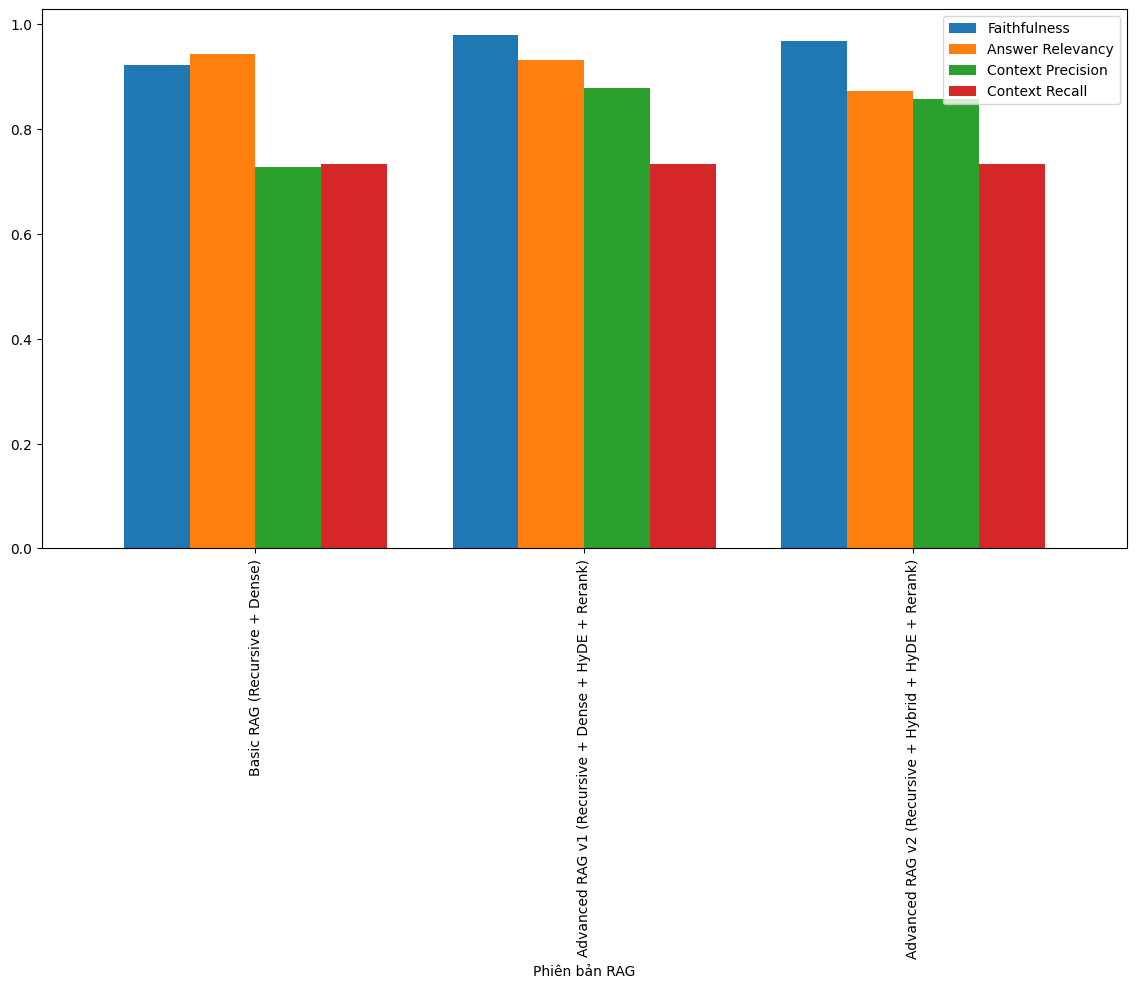

In [10]:
# Điền kết quả thực tế thu được từ bước 6 để tổng hợp bảng so sánh hoàn chỉnh
summary_data = {
    "Phiên bản RAG": [
        "Basic RAG (Recursive + Dense)",
        "Advanced RAG v1 (Recursive + Dense + HyDE + Rerank)",
        "Advanced RAG v2 (Recursive + Hybrid + HyDE + Rerank)",
    ],
    "Faithfulness": [0.9214, 0.9782, 0.9667], 
    "Answer Relevancy": [0.9422, 0.9310, 0.8727],
    "Context Precision": [0.7278, 0.8778, 0.8556],
    "Context Recall": [0.7333, 0.7333, 0.7333]
}

df_summary = pd.DataFrame(summary_data)
display(df_summary)

# so sanhs 3 phieen banr RAG 
ax = df_summary.plot(x="Phiên bản RAG", y=["Faithfulness", "Answer Relevancy", "Context Precision", "Context Recall"], kind="bar", figsize=(14, 7), width=0.8)
plt.title("So sánh Hiệu năng RAG qua 4 phiên bản cấu hình", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Scores", fontsize=12)
plt.xticks(rotation=15, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

# Lưu đồ thị so sánh hệ thống
plt.savefig("../reports/ragas_strategy_comparison.png", dpi=300)
plt.show()